In [2]:
from pathlib import Path
import os
import re

import numpy as np
import pandas as pd
import cv2
import pydicom
from scipy.ndimage import label

from tqdm.auto import tqdm
import plistlib
import warnings

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

## 2. Config

In [3]:
# Project/data roots
# Run this notebook from the repository root. The helper below also supports being
# run from inside dataprep/ by walking upward until it finds data/Gated_release_final.
def find_project_root(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "Gated_release_final").is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find data/Gated_release_final from {start}. "
        "Run from the repo root or update PROJECT_ROOT manually."
    )

PROJECT_ROOT = find_project_root()
DATA_RELEASE_ROOT = PROJECT_ROOT / "data" / "Gated_release_final"
RAW_DICOM_ROOT = DATA_RELEASE_ROOT / "patient"
XML_ROOT = DATA_RELEASE_ROOT / "calcium_xml"
PROCESSED_DATA_ROOT = DATA_RELEASE_ROOT / "processed_data"
PROCESSED_IMAGE_DIR = PROCESSED_DATA_ROOT / "images"
PROCESSED_MASK_DIR = PROCESSED_DATA_ROOT / "masks"
CHECKPOINT_DIR = PROJECT_ROOT / "models" / "checkpoints"

# Use raw case ids here. Case "1" maps to:
#   DICOM folder: data/Gated_release_final/patient/1
#   XML file:     data/Gated_release_final/calcium_xml/1.xml
#   model input:  data/Gated_release_final/processed_data/images/001.npy
CASE_IDS = ["1", "2"]
CASE_DIRS = [RAW_DICOM_ROOT / str(int(case_id)) for case_id in CASE_IDS]

WEIGHTS_PATH = CHECKPOINT_DIR / "best_weights.pt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Reuse prepared 2.5D arrays for model inference instead of regenerating them from DICOM.
USE_PREPARED_MODEL_INPUTS = True

# Model preprocessing should match training preprocessing used for prepared_data/images.
HU_LOW = -200
HU_HIGH = 1000

# Agatston scoring constants
AGATSTON_HU_THRESHOLD = 130
MIN_AREA_MM2 = 1.0

# Model probability threshold, only used in inference section.
MODEL_THRESHOLD = 0.6


def case_filename(case_id) -> str:
    """Convert raw case id/folder name to processed .npy stem, e.g. 1 -> 001."""
    case_id = str(case_id)
    return f"{int(case_id):03d}" if case_id.isdigit() else case_id


def get_case_paths(case_id):
    """Return all files/folders for a case using the dataset naming convention."""
    raw_case_id = str(int(case_id)) if str(case_id).isdigit() else str(case_id)
    processed_name = case_filename(raw_case_id)
    return {
        "case_id": raw_case_id,
        "dicom_dir": RAW_DICOM_ROOT / raw_case_id,
        "xml_path": XML_ROOT / f"{raw_case_id}.xml",
        "processed_image_path": PROCESSED_IMAGE_DIR / f"{processed_name}.npy",
        "processed_mask_path": PROCESSED_MASK_DIR / f"{processed_name}.npy",
    }


print("Project root:", PROJECT_ROOT)
print("Raw DICOM root:", RAW_DICOM_ROOT)
print("XML root:", XML_ROOT)
print("Prepared model input dir:", PROCESSED_IMAGE_DIR)
print("Weights path:", WEIGHTS_PATH)
print("Device:", DEVICE)

for case_id in CASE_IDS:
    paths = get_case_paths(case_id)
    print(f"\nCase {case_id}")
    print("  DICOM dir exists:", paths["dicom_dir"].exists(), paths["dicom_dir"])
    print("  XML exists:", paths["xml_path"].exists(), paths["xml_path"])
    print("  Prepared input exists:", paths["processed_image_path"].exists(), paths["processed_image_path"])

print("\nWeights exists:", WEIGHTS_PATH.exists())


Project root: C:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2
Raw DICOM root: C:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\data\Gated_release_final\patient
XML root: C:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\data\Gated_release_final\calcium_xml
Prepared model input dir: C:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\data\Gated_release_final\processed_data\images
Weights path: C:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\models\checkpoints\best_weights.pt
Device: cuda

Case 1
  DICOM dir exists: True C:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\data\Gated_release_final\patient\1
  XML exists: True C:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\data\Gated_release_final\calcium_xml\1.xml
  Prepared input exists

## 3. DICOM loading and HU conversion

This section reads DICOM slices recursively from each case folder and converts the raw pixel values to true HU:

```python
HU = pixel_array * RescaleSlope + RescaleIntercept
```

Do not clip or normalize this `hu_volume`; this is what Agatston scoring needs.

In [4]:
def is_probably_dicom(path: Path) -> bool:
    """Return True if the file can likely be read as a DICOM file."""
    if not path.is_file():
        return False
    if path.suffix.lower() in [".xml", ".csv", ".txt", ".json", ".npy", ".pt", ".pth", ".ipynb"]:
        return False
    return True


def dicom_to_hu(ds):
    """Convert a pydicom dataset to true Hounsfield Units."""
    raw = ds.pixel_array.astype(np.float32)
    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    hu = raw * slope + intercept
    return hu.astype(np.float32)


def get_slice_z(ds, fallback_index=0):
    """Get anatomical z-position when available."""
    if hasattr(ds, "ImagePositionPatient"):
        return float(ds.ImagePositionPatient[2])
    if hasattr(ds, "SliceLocation"):
        return float(ds.SliceLocation)
    return float(fallback_index)


def load_dicom_volume(case_dir: Path):
    """
    Read all DICOM slices from one case folder.

    Returns
    -------
    slices: list of dicts
    hu_volume: np.ndarray, shape (D, H, W)
    spacing_y: float
    spacing_x: float
    """
    candidate_paths = sorted([p for p in case_dir.rglob("*") if is_probably_dicom(p)])

    slices = []

    for i, path in enumerate(tqdm(candidate_paths, desc=f"Reading DICOM: {case_dir.name}")):
        try:
            ds = pydicom.dcmread(str(path), force=True)

            if not hasattr(ds, "PixelData"):
                continue

            hu = dicom_to_hu(ds)

            pixel_spacing = getattr(ds, "PixelSpacing", [1.0, 1.0])
            spacing_y = float(pixel_spacing[0])  # row spacing
            spacing_x = float(pixel_spacing[1])  # column spacing

            instance = int(getattr(ds, "InstanceNumber", i))
            z = get_slice_z(ds, fallback_index=i)
            sop_uid = str(getattr(ds, "SOPInstanceUID", ""))

            slices.append({
                "path": path,
                "ds": ds,
                "hu": hu,
                "z": z,
                "instance": instance,
                "sop_uid": sop_uid,
                "spacing_y": spacing_y,
                "spacing_x": spacing_x,
            })

        except Exception:
            # Some files may not be DICOM. Skip silently.
            continue

    if len(slices) == 0:
        raise RuntimeError(f"No valid DICOM slices found in {case_dir}")

    # Sort by anatomical z. If z is unavailable, fallback values keep stable order.
    slices = sorted(slices, key=lambda x: (x["z"], x["instance"]))

    hu_volume = np.stack([s["hu"] for s in slices], axis=0).astype(np.float32)

    spacing_y = float(slices[0]["spacing_y"])
    spacing_x = float(slices[0]["spacing_x"])

    print(f"Case: {case_dir.name}")
    print("HU volume shape:", hu_volume.shape)
    print("HU range:", float(hu_volume.min()), float(hu_volume.max()))
    print("Pixel spacing y/x:", spacing_y, spacing_x)
    print("z range:", slices[0]["z"], "to", slices[-1]["z"])

    return slices, hu_volume, spacing_y, spacing_x

## 4. XML plist parser

Your XML annotations are Apple plist-style files.

The important fields are:

```text
Images
  → ImageIndex
  → ROIs
      → Name
      → NumberOfPoints
      → Point_px
      → Point_mm
      → Center
      → Max / Mean / Min
```

We use `Point_px` to create the binary mask polygon, and use the ROI z-coordinate from `Center` or `Point_mm` to match the ROI to the correct DICOM slice.

In [5]:
def parse_tuple_string(s):
    """
    Convert strings like:
    '(178.003922, 202.000000)'
    '(10.142126, -193.171875, -214.750000)'
    into tuples of floats.
    """
    nums = re.findall(r"-?\d+\.?\d*", str(s))
    return tuple(float(x) for x in nums)


def find_roi_z(roi):
    """Find ROI z-coordinate from Center or first Point_mm."""
    center = roi.get("Center", None)
    if center is not None:
        vals = parse_tuple_string(center)
        if len(vals) >= 3:
            return float(vals[2])

    point_mm = roi.get("Point_mm", [])
    if len(point_mm) > 0:
        vals = parse_tuple_string(point_mm[0])
        if len(vals) >= 3:
            return float(vals[2])

    return None


def read_plist_xml(xml_path: Path):
    """Read Apple plist XML annotation."""
    with open(xml_path, "rb") as f:
        return plistlib.load(f)


def xml_plist_to_mask_volume(xml_path: Path, slices, hu_volume):
    """
    Convert plist XML CAC ROIs into a binary 3D mask.

    Parameters
    ----------
    xml_path:
        XML plist path.
    slices:
        List from load_dicom_volume().
    hu_volume:
        True HU volume, shape (D, H, W).

    Returns
    -------
    mask_volume:
        Binary mask, shape (D, H, W).
    roi_df:
        ROI-level debug table.
    """
    D, H, W = hu_volume.shape
    mask_volume = np.zeros((D, H, W), dtype=np.uint8)

    z_values = np.array([s["z"] for s in slices], dtype=np.float32)

    data = read_plist_xml(xml_path)

    roi_rows = []
    total_rois = 0
    used_rois = 0

    for image_entry in data.get("Images", []):
        image_index = int(image_entry.get("ImageIndex", -1))
        rois = image_entry.get("ROIs", [])

        for roi_idx, roi in enumerate(rois):
            total_rois += 1

            n_points = int(roi.get("NumberOfPoints", 0))
            point_px = roi.get("Point_px", [])

            # Ignore empty placeholder ROIs.
            if n_points < 3 or len(point_px) < 3:
                continue

            pts = np.array(
                [parse_tuple_string(p)[:2] for p in point_px],
                dtype=np.float32
            )

            if pts.shape[0] < 3:
                continue

            # Best mapping: match annotation z-coordinate to DICOM z-coordinate.
            roi_z = find_roi_z(roi)

            if roi_z is not None:
                slice_idx = int(np.argmin(np.abs(z_values - roi_z)))
                z_diff = float(abs(z_values[slice_idx] - roi_z))
            else:
                # Fallback: use ImageIndex only if z is unavailable.
                if 0 <= image_index < D:
                    slice_idx = image_index
                elif 1 <= image_index <= D:
                    slice_idx = image_index - 1
                else:
                    continue
                z_diff = np.nan

            pts_i = np.round(pts).astype(np.int32)

            # Point_px is stored as (x, y).
            pts_i[:, 0] = np.clip(pts_i[:, 0], 0, W - 1)
            pts_i[:, 1] = np.clip(pts_i[:, 1], 0, H - 1)

            roi_mask = np.zeros((H, W), dtype=np.uint8)
            cv2.fillPoly(roi_mask, [pts_i], 1)

            mask_volume[slice_idx] = np.logical_or(mask_volume[slice_idx], roi_mask).astype(np.uint8)

            used_rois += 1

            roi_pixels = roi_mask.astype(bool)
            hu_vals = hu_volume[slice_idx][roi_pixels]

            roi_rows.append({
                "xml_file": xml_path.name,
                "image_index_xml": image_index,
                "roi_idx": roi_idx,
                "slice_idx_used": slice_idx,
                "roi_z_xml": roi_z,
                "dicom_z_used": float(z_values[slice_idx]),
                "z_diff_mm": z_diff,
                "artery_name": roi.get("Name", ""),
                "n_points": n_points,
                "pixel_count": int(roi_pixels.sum()),
                "xml_min": float(roi.get("Min", np.nan)),
                "xml_mean": float(roi.get("Mean", np.nan)),
                "xml_max": float(roi.get("Max", np.nan)),
                "calc_min_hu": float(np.min(hu_vals)) if len(hu_vals) > 0 else np.nan,
                "calc_mean_hu": float(np.mean(hu_vals)) if len(hu_vals) > 0 else np.nan,
                "calc_max_hu": float(np.max(hu_vals)) if len(hu_vals) > 0 else np.nan,
            })

    roi_df = pd.DataFrame(roi_rows)

    print("XML:", xml_path)
    print("Total ROIs:", total_rois)
    print("Used non-empty ROIs:", used_rois)
    print("Positive mask pixels:", int(mask_volume.sum()))

    return mask_volume, roi_df


def find_xml_file(case_dir: Path):
    """Find the calcium XML for this raw case folder in XML_ROOT."""
    xml_path = XML_ROOT / f"{case_dir.name}.xml"
    if not xml_path.exists():
        raise FileNotFoundError(
            f"No XML annotation found for case {case_dir.name}: {xml_path}"
        )
    return xml_path


## 5. Agatston scoring functions

For each connected lesion:

```text
lesion_score = lesion_area_mm2 × density_factor
```

Density factor:

```text
130–199 HU → 1
200–299 HU → 2
300–399 HU → 3
≥400 HU    → 4
```

In [6]:
def density_factor(max_hu):
    """Agatston density factor from lesion maximum HU."""
    if 130 <= max_hu < 200:
        return 1
    elif 200 <= max_hu < 300:
        return 2
    elif 300 <= max_hu < 400:
        return 3
    elif max_hu >= 400:
        return 4
    else:
        return 0


def agatston_score_case(
    mask_volume,
    hu_volume,
    spacing_y,
    spacing_x,
    hu_threshold=130,
    min_area_mm2=1.0,
):
    """
    Compute Agatston score from binary mask + true HU volume.

    Parameters
    ----------
    mask_volume:
        Binary mask, shape (D, H, W).
    hu_volume:
        True HU volume, shape (D, H, W).
    spacing_y, spacing_x:
        DICOM pixel spacing in mm.
    hu_threshold:
        Standard CAC threshold, usually 130 HU.
    min_area_mm2:
        Small-component filtering threshold.

    Returns
    -------
    total_score:
        Case-level Agatston score.
    lesion_df:
        Lesion-level scoring details.
    """
    assert mask_volume.shape == hu_volume.shape, (mask_volume.shape, hu_volume.shape)

    pixel_area = float(spacing_y) * float(spacing_x)
    total_score = 0.0
    lesion_rows = []

    for z in range(mask_volume.shape[0]):
        mask = mask_volume[z].astype(bool)
        hu = hu_volume[z].astype(np.float32)

        # Score only pixels that are both inside the mask and >= 130 HU.
        scoring_mask = mask & (hu >= hu_threshold)

        labeled, num_components = label(
            scoring_mask,
            structure=np.ones((3, 3), dtype=np.uint8)
        )

        for component_id in range(1, num_components + 1):
            lesion = labeled == component_id
            pixel_count = int(lesion.sum())

            if pixel_count == 0:
                continue

            area_mm2 = pixel_count * pixel_area

            if area_mm2 < min_area_mm2:
                continue

            max_hu = float(hu[lesion].max())
            factor = density_factor(max_hu)
            lesion_score = area_mm2 * factor

            total_score += lesion_score

            lesion_rows.append({
                "slice_idx": z,
                "component_id": component_id,
                "pixel_count": pixel_count,
                "area_mm2": area_mm2,
                "max_hu": max_hu,
                "density_factor": factor,
                "lesion_score": lesion_score,
            })

    lesion_df = pd.DataFrame(lesion_rows)
    return float(total_score), lesion_df

## 6. Visualization helpers

In [7]:
def _as_3d_mask(mask, name="mask"):
    """
    Convert mask to shape (D, H, W).
    Accepts:
    - (D, H, W)
    - (D, 1, H, W)
    """
    mask = np.asarray(mask)

    if mask.ndim == 4 and mask.shape[1] == 1:
        mask = mask[:, 0]

    if mask.ndim != 3:
        raise ValueError(f"{name} must have shape (D,H,W) or (D,1,H,W), got {mask.shape}")

    return mask


def _check_volume_mask_shapes(hu_volume, *masks):
    hu_volume = np.asarray(hu_volume)

    if hu_volume.ndim != 3:
        raise ValueError(f"hu_volume must have shape (D,H,W), got {hu_volume.shape}")

    checked = []
    for i, mask in enumerate(masks):
        mask = _as_3d_mask(mask, name=f"mask_{i}")
        if mask.shape != hu_volume.shape:
            raise ValueError(
                f"Shape mismatch: hu_volume {hu_volume.shape} vs mask_{i} {mask.shape}"
            )
        checked.append(mask)

    return checked


def visualize_mask_overlay(hu_volume, mask_volume, idx=None, title="Mask Overlay"):
    """
    Show one HU slice with a single mask overlay.

    Uses RGBA overlay. This avoids the masked_where RGB shape bug.
    """
    (mask_volume,) = _check_volume_mask_shapes(hu_volume, mask_volume)

    if idx is None:
        positive = np.where(mask_volume.sum(axis=(1, 2)) > 0)[0]
        idx = int(positive[len(positive) // 2]) if len(positive) > 0 else len(hu_volume) // 2

    hu = hu_volume[idx]
    mask = mask_volume[idx].astype(bool)

    rgba = np.zeros((*mask.shape, 4), dtype=np.float32)
    rgba[mask] = [0.0, 1.0, 0.0, 0.65]  # green with alpha

    plt.figure(figsize=(6, 6))
    plt.imshow(hu, cmap="gray", vmin=-200, vmax=800)
    plt.imshow(rgba)
    plt.title(f"{title} | slice {idx}")
    plt.axis("off")
    plt.show()


def choose_most_informative_slice(gt_mask, pred_mask):
    """
    Pick the slice with the largest combined GT + predicted positive area.
    """
    gt_mask = _as_3d_mask(gt_mask, "gt_mask")
    pred_mask = _as_3d_mask(pred_mask, "pred_mask")

    if gt_mask.shape != pred_mask.shape:
        raise ValueError(f"GT shape {gt_mask.shape} != pred shape {pred_mask.shape}")

    score = gt_mask.sum(axis=(1, 2)) + pred_mask.sum(axis=(1, 2))
    if score.max() == 0:
        return len(score) // 2
    return int(np.argmax(score))


def visualize_gt_pred_overlay(hu_volume, gt_mask, pred_mask, idx=None, title="GT vs Prediction Overlay"):
    """
    Diagnostic overlay:
    Green = true positive overlap
    Red   = false positive
    Blue  = false negative

    This function fixes the error:
    "Inconsistent shape between the condition and the input (got (512,512) and (512,512,3))"

    Reason:
    np.ma.masked_where() was being applied with a 2D condition to a 3D RGB image.
    This version uses a proper RGBA image with an alpha channel instead.
    """
    gt_mask, pred_mask = _check_volume_mask_shapes(hu_volume, gt_mask, pred_mask)

    if idx is None:
        idx = choose_most_informative_slice(gt_mask, pred_mask)

    hu = hu_volume[idx]
    gt = gt_mask[idx].astype(bool)
    pred = pred_mask[idx].astype(bool)

    tp = gt & pred
    fp = (~gt) & pred
    fn = gt & (~pred)

    rgba = np.zeros((*gt.shape, 4), dtype=np.float32)
    rgba[tp] = [0.0, 1.0, 0.0, 0.75]  # green
    rgba[fp] = [1.0, 0.0, 0.0, 0.75]  # red
    rgba[fn] = [0.0, 0.2, 1.0, 0.75]  # blue

    plt.figure(figsize=(7, 7))
    plt.imshow(hu, cmap="gray", vmin=-200, vmax=800)
    plt.imshow(rgba)
    plt.title(f"{title} | slice {idx}\nGreen=TP, Red=FP, Blue=FN")
    plt.axis("off")
    plt.show()


def visualize_gt_pred_side_by_side(hu_volume, gt_mask, pred_mask, idx=None):
    """
    Show GT, prediction, and diagnostic overlay side-by-side.
    """
    gt_mask, pred_mask = _check_volume_mask_shapes(hu_volume, gt_mask, pred_mask)

    if idx is None:
        idx = choose_most_informative_slice(gt_mask, pred_mask)

    hu = hu_volume[idx]
    gt = gt_mask[idx].astype(bool)
    pred = pred_mask[idx].astype(bool)

    tp = gt & pred
    fp = (~gt) & pred
    fn = gt & (~pred)

    gt_rgba = np.zeros((*gt.shape, 4), dtype=np.float32)
    pred_rgba = np.zeros((*pred.shape, 4), dtype=np.float32)
    diag_rgba = np.zeros((*gt.shape, 4), dtype=np.float32)

    gt_rgba[gt] = [0.0, 1.0, 0.0, 0.65]
    pred_rgba[pred] = [1.0, 0.0, 0.0, 0.65]

    diag_rgba[tp] = [0.0, 1.0, 0.0, 0.75]
    diag_rgba[fp] = [1.0, 0.0, 0.0, 0.75]
    diag_rgba[fn] = [0.0, 0.2, 1.0, 0.75]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(hu, cmap="gray", vmin=-200, vmax=800)
    axes[0].imshow(gt_rgba)
    axes[0].set_title(f"GT mask | slice {idx}")
    axes[0].axis("off")

    axes[1].imshow(hu, cmap="gray", vmin=-200, vmax=800)
    axes[1].imshow(pred_rgba)
    axes[1].set_title(f"Predicted mask | slice {idx}")
    axes[1].axis("off")

    axes[2].imshow(hu, cmap="gray", vmin=-200, vmax=800)
    axes[2].imshow(diag_rgba)
    axes[2].set_title("Diagnostic\nGreen=TP, Red=FP, Blue=FN")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


def debug_case_shapes(case_outputs):
    """
    Print shape checks for all cases.
    Run before visualization if anything looks suspicious.
    """
    for case_name, outputs in case_outputs.items():
        hu = outputs["hu_volume"]
        gt = outputs["gt_mask_volume"]
        pred = outputs.get("pred_mask_volume", None)

        print(f"\nCASE {case_name}")
        print("HU shape:", np.asarray(hu).shape)
        print("GT shape:", np.asarray(gt).shape)

        if pred is not None:
            print("Pred shape:", np.asarray(pred).shape)
            _check_volume_mask_shapes(hu, gt, pred)
            print("Shape check: OK")
        else:
            _check_volume_mask_shapes(hu, gt)
            print("Shape check: OK, but pred_mask_volume is not available yet")

## 7. Process one case: XML mask + GT Agatston score

In [8]:
def process_gt_agatston_for_case(case_dir: Path, min_area_mm2=MIN_AREA_MM2):
    """Load DICOM, parse XML mask, and calculate GT Agatston."""
    slices, hu_volume, spacing_y, spacing_x = load_dicom_volume(case_dir)

    xml_path = find_xml_file(case_dir)
    paths = get_case_paths(case_dir.name)

    gt_mask_volume, roi_df = xml_plist_to_mask_volume(
        xml_path=xml_path,
        slices=slices,
        hu_volume=hu_volume
    )

    gt_agatston, gt_lesions_df = agatston_score_case(
        mask_volume=gt_mask_volume,
        hu_volume=hu_volume,
        spacing_y=spacing_y,
        spacing_x=spacing_x,
        hu_threshold=AGATSTON_HU_THRESHOLD,
        min_area_mm2=min_area_mm2,
    )

    summary = {
        "case": case_dir.name,
        "num_slices": int(hu_volume.shape[0]),
        "height": int(hu_volume.shape[1]),
        "width": int(hu_volume.shape[2]),
        "spacing_y": float(spacing_y),
        "spacing_x": float(spacing_x),
        "gt_positive_pixels": int(gt_mask_volume.sum()),
        "num_gt_lesions_scored": int(len(gt_lesions_df)),
        "gt_agatston": float(gt_agatston),
        "dicom_dir": str(paths["dicom_dir"]),
        "xml_path": str(paths["xml_path"]),
        "processed_image_path": str(paths["processed_image_path"]),
    }

    outputs = {
        "case_id": case_dir.name,
        "slices": slices,
        "hu_volume": hu_volume,
        "gt_mask_volume": gt_mask_volume,
        "roi_df": roi_df,
        "gt_lesions_df": gt_lesions_df,
        "spacing_y": spacing_y,
        "spacing_x": spacing_x,
        "xml_path": xml_path,
        "processed_image_path": paths["processed_image_path"],
        "processed_mask_path": paths["processed_mask_path"],
    }

    return summary, outputs


## 8. Run GT Agatston scoring for all case folders

In [9]:
gt_summaries = []
case_outputs = {}

for case_dir in CASE_DIRS:
    print("\n" + "=" * 80)
    print("Processing case:", case_dir.name)

    summary, outputs = process_gt_agatston_for_case(case_dir)

    gt_summaries.append(summary)
    case_outputs[case_dir.name] = outputs

gt_summary_df = pd.DataFrame(gt_summaries)
gt_summary_df


Processing case: 1


Reading DICOM: 1:   0%|          | 0/57 [00:00<?, ?it/s]

Case: 1
HU volume shape: (57, 512, 512)
HU range: -1024.0 1239.0
Pixel spacing y/x: 0.3828125 0.3828125
z range: -250.75 to -82.75
XML: C:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\data\Gated_release_final\calcium_xml\1.xml
Total ROIs: 20
Used non-empty ROIs: 16
Positive mask pixels: 1115

Processing case: 2


Reading DICOM: 2:   0%|          | 0/46 [00:00<?, ?it/s]

Case: 2
HU volume shape: (46, 512, 512)
HU range: -1024.0 3071.0
Pixel spacing y/x: 0.3203125 0.3203125
z range: -220.25 to -85.25
XML: C:\Users\Quoc Thai\Downloads\AIO Conquer 3 - medical\cocacoronarycalciumandchestcts-2\data\Gated_release_final\calcium_xml\2.xml
Total ROIs: 18
Used non-empty ROIs: 13
Positive mask pixels: 656


,case,num_slices,height,width,spacing_y,spacing_x,gt_positive_pixels,num_gt_lesions_scored,gt_agatston,dicom_dir,xml_path,processed_image_path
0,1,57,512,512,0.382812,0.382812,1115,13,367.389343,C:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,C:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,C:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...
1,2,46,512,512,0.320312,0.320312,656,10,111.628906,C:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,C:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...,C:\Users\Quoc Thai\Downloads\AIO Conquer 3 - m...


## 9. Inspect ROI-to-DICOM alignment

Check `z_diff_mm`. If the parser is correct, this should usually be very small.

Also compare `xml_max` with `calc_max_hu`. They do not need to be exactly identical because polygon filling can differ slightly, but they should be in the same general range.

In [10]:
for case_name, outputs in case_outputs.items():
    print("\nCASE:", case_name)
    display_cols = [
        "image_index_xml",
        "slice_idx_used",
        "roi_z_xml",
        "dicom_z_used",
        "z_diff_mm",
        "artery_name",
        "n_points",
        "pixel_count",
        "xml_max",
        "calc_max_hu",
    ]
    display(outputs["roi_df"][display_cols].head(20))


CASE: 1


,image_index_xml,slice_idx_used,roi_z_xml,dicom_z_used,z_diff_mm,artery_name,n_points,pixel_count,xml_max,calc_max_hu
0,12,12,-214.75,-214.75,0.0,Right Coronary Artery,20,34,285.0,285.0
1,19,19,-193.75,-193.75,0.0,Right Coronary Artery,14,22,186.0,186.0
2,26,26,-172.75,-172.75,0.0,Right Coronary Artery,8,12,139.0,139.0
3,27,27,-169.75,-169.75,0.0,Right Coronary Artery,36,93,834.0,834.0
4,27,27,-169.75,-169.75,0.0,Right Coronary Artery,12,18,185.0,185.0
5,28,28,-166.75,-166.75,0.0,Right Coronary Artery,34,77,585.0,585.0
6,39,39,-133.75,-133.75,0.0,Left Anterior Descending Artery,24,44,206.0,206.0
7,39,39,-133.75,-133.75,0.0,Left Anterior Descending Artery,12,19,159.0,159.0
8,40,40,-130.75,-130.75,0.0,Left Anterior Descending Artery,84,301,934.0,934.0
9,40,40,-130.75,-130.75,0.0,Left Anterior Descending Artery,86,197,323.0,323.0



CASE: 2


,image_index_xml,slice_idx_used,roi_z_xml,dicom_z_used,z_diff_mm,artery_name,n_points,pixel_count,xml_max,calc_max_hu
0,23,23,-151.25,-151.25,0.0,Left Circumflex Artery,32,75,387.0,387.0
1,24,24,-148.25,-148.25,0.0,Left Circumflex Artery,28,62,390.0,390.0
2,32,32,-124.25,-124.25,0.0,Left Circumflex Artery,22,46,288.0,288.0
3,32,32,-124.25,-124.25,0.0,Left Anterior Descending Artery,20,35,181.0,181.0
4,33,33,-121.25,-121.25,0.0,Left Anterior Descending Artery,34,85,536.0,536.0
5,33,33,-121.25,-121.25,0.0,Left Circumflex Artery,14,20,160.0,160.0
6,34,34,-118.25,-118.25,0.0,Left Anterior Descending Artery,38,90,437.0,437.0
7,35,35,-115.25,-115.25,0.0,Left Anterior Descending Artery,48,74,208.0,208.0
8,35,35,-115.25,-115.25,0.0,Left Anterior Descending Artery,14,18,156.0,156.0
9,36,36,-112.25,-112.25,0.0,Left Anterior Descending Artery,32,71,392.0,392.0


## 10. Visualize GT annotation masks

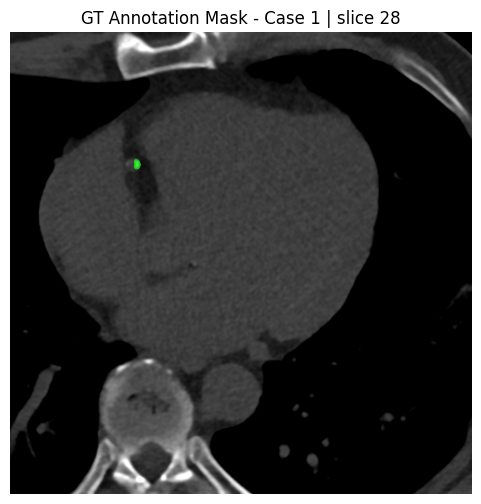

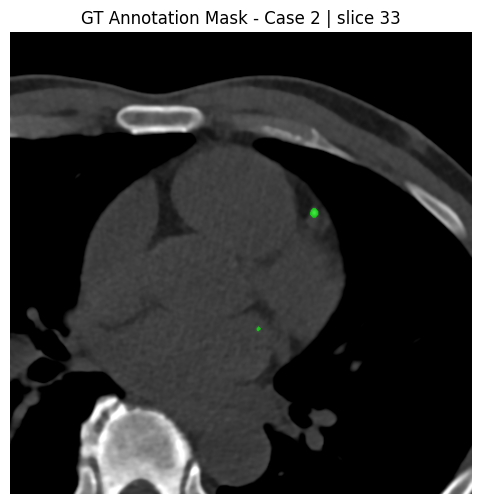

In [11]:
for case_name, outputs in case_outputs.items():
    visualize_mask_overlay(
        hu_volume=outputs["hu_volume"],
        mask_volume=outputs["gt_mask_volume"],
        title=f"GT Annotation Mask - Case {case_name}"
    )

## 11. Save GT Agatston results

In [12]:
RESULTS_DIR = Path("agatston_results")
RESULTS_DIR.mkdir(exist_ok=True)

gt_summary_df.to_csv(RESULTS_DIR / "gt_agatston_summary.csv", index=False)

for case_name, outputs in case_outputs.items():
    case_dir = RESULTS_DIR / f"case_{case_name}"
    case_dir.mkdir(exist_ok=True)

    outputs["roi_df"].to_csv(case_dir / "roi_debug.csv", index=False)
    outputs["gt_lesions_df"].to_csv(case_dir / "gt_lesions_agatston.csv", index=False)

    np.save(case_dir / "gt_mask_volume.npy", outputs["gt_mask_volume"])
    np.save(case_dir / "hu_volume.npy", outputs["hu_volume"])

print("Saved GT results to:", RESULTS_DIR)

Saved GT results to: agatston_results


# Predicted-mask Agatston score

Use this section only if you want to calculate Agatston from your trained model prediction.

Important: you must paste the exact same model architecture used to create `best_weights.pt`.

If the architecture does not match, loading the weights will fail.

## 12. Build model input from raw HU

This must match your training preprocessing.

In [13]:
def normalize_hu_for_model(hu_volume, hu_low=HU_LOW, hu_high=HU_HIGH):
    """Clip/window HU and normalize to 0-1 for model input."""
    x = np.clip(hu_volume, hu_low, hu_high)
    x = (x - hu_low) / (hu_high - hu_low)
    return x.astype(np.float32)


def build_3slice_input(hu_volume, hu_low=HU_LOW, hu_high=HU_HIGH):
    """
    Convert HU volume to model input shape (D, 3, H, W).

    Channel 0 = previous slice
    Channel 1 = current slice
    Channel 2 = next slice
    """
    img = normalize_hu_for_model(hu_volume, hu_low, hu_high)

    D, H, W = img.shape
    X = np.zeros((D, 3, H, W), dtype=np.float32)

    for i in range(D):
        prev_i = max(i - 1, 0)
        next_i = min(i + 1, D - 1)

        X[i, 0] = img[prev_i]
        X[i, 1] = img[i]
        X[i, 2] = img[next_i]

    return X


def load_prepared_model_input(case_id, hu_volume=None):
    """Load processed_data/images/<case>.npy for model inference when available."""
    image_path = get_case_paths(case_id)["processed_image_path"]
    if not image_path.exists():
        return None

    X = np.load(image_path, mmap_mode="r")

    if X.ndim != 4 or X.shape[1] != 3:
        raise ValueError(f"Prepared model input must have shape (D,3,H,W), got {X.shape}: {image_path}")

    if hu_volume is not None and X.shape[0] != hu_volume.shape[0]:
        raise ValueError(
            f"Slice-count mismatch for case {case_id}: prepared input has {X.shape[0]} "
            f"slices but HU volume has {hu_volume.shape[0]} slices."
        )

    return X


## 13. Paste your baseline model architecture here

This placeholder intentionally raises an error. Replace it with the exact model class from your training notebook.

For example, if your training code used `UNetModel(...)`, paste the full `UNetModel` definition here.

In [14]:
# Two layers learn richer local patterns: edges, bright dense structures, shape boundaries, lesion-like textures.
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels, out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

# Downsampling block : shrinks spatial size, increase semantic richness
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)

# Upsampling block
class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):
        x = self.up(x)

        # In case of minor shape mismatch due to odd dimensions
        if x.shape[-2:] != skip.shape[-2:]:
            x = nn.functional.interpolate(
                x,
                size=skip.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        # skip: high-resolution details from encoder
        # x: upsampled decoder features
        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x

# 2.5D U-Net
class UNetModel(nn.Module):
    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        base_channels=32
    ):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, base_channels)              # 32
        self.enc2 = DownBlock(base_channels, base_channels * 2)         # 64
        self.enc3 = DownBlock(base_channels * 2, base_channels * 4)     # 128
        self.enc4 = DownBlock(base_channels * 4, base_channels * 8)     # 256

        # Bottleneck
        self.bottleneck = DownBlock(
            base_channels * 8,
            base_channels * 16
        )                                                               # 512

        # Decoder: rebuild full image resolution
        self.up4 = UpBlock(
            in_channels=base_channels * 16,
            skip_channels=base_channels * 8,
            out_channels=base_channels * 8
        )

        self.up3 = UpBlock(
            in_channels=base_channels * 8,
            skip_channels=base_channels * 4,
            out_channels=base_channels * 4
        )

        self.up2 = UpBlock(
            in_channels=base_channels * 4,
            skip_channels=base_channels * 2,
            out_channels=base_channels * 2
        )

        self.up1 = UpBlock(
            in_channels=base_channels * 2,
            skip_channels=base_channels,
            out_channels=base_channels
        )

        # Final segmentation head
        self.out_conv = nn.Conv2d(
            base_channels,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):
        # Encoder
        s1 = self.enc1(x)       # [B, 16, H, W]
        s2 = self.enc2(s1)      # [B, 32, H/2, W/2]
        s3 = self.enc3(s2)      # [B, 64, H/4, W/4]
        s4 = self.enc4(s3)      # [B, 128, H/8, W/8]

        # Bottleneck
        b = self.bottleneck(s4) # [B, 256, H/16, W/16]

        # Decoder
        d4 = self.up4(b, s4)
        d3 = self.up3(d4, s3)
        d2 = self.up2(d3, s2)
        d1 = self.up1(d2, s1)

        # Output logits
        logits = self.out_conv(d1)
        return logits

## 14. Load model weights

Run this only after replacing the placeholder model with the real architecture.

In [15]:
def load_trained_model(weights_path=WEIGHTS_PATH):
    model = UNetModel(
        in_channels=3,
        out_channels=1,
        base_channels=16,
    ).to(DEVICE)

    checkpoint = torch.load(weights_path, map_location=DEVICE)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint

    # Remove possible 'module.' prefix from DataParallel training.
    clean_state_dict = {}
    for k, v in state_dict.items():
        new_k = k.replace("module.", "")
        clean_state_dict[new_k] = v

    model.load_state_dict(clean_state_dict, strict=True)
    model.eval()

    return model


# Uncomment only after you paste the real model architecture.
model = load_trained_model(WEIGHTS_PATH)
print("Model loaded.")

Model loaded.


## Sanity check

In [16]:
case_name = list(case_outputs.keys())[0]
hu_volume = case_outputs[case_name]["hu_volume"]

X_test = build_3slice_input(hu_volume)
x = torch.from_numpy(X_test[:2]).float().to(DEVICE)

model.eval()
with torch.no_grad():
    logits = model(x)

print("Input shape:", x.shape)
print("Output shape:", logits.shape)
print("Logits min/max:", logits.min().item(), logits.max().item())

Input shape: torch.Size([2, 3, 512, 512])
Output shape: torch.Size([2, 1, 512, 512])
Logits min/max: -69.6093978881836 -6.761256694793701


## 15. Predict mask volume

In [17]:
@torch.no_grad()
def predict_mask_volume(model, hu_volume, threshold=MODEL_THRESHOLD, batch_size=8, model_input=None):
    """Predict binary CAC mask volume from prepared 2.5D input or raw HU volume."""
    if model_input is None:
        X = build_3slice_input(hu_volume)
        input_source = "generated from HU volume"
    else:
        X = model_input
        input_source = "prepared processed_data/images .npy"

    print("Model input source:", input_source)

    pred_masks = []

    model.eval()

    for start in tqdm(range(0, len(X), batch_size), desc="Predicting"):
        end = start + batch_size

        x_np = np.asarray(X[start:end], dtype=np.float32)
        x = torch.from_numpy(x_np).float().to(DEVICE)

        logits = model(x)
        probs = torch.sigmoid(logits)

        pred = (probs >= threshold).cpu().numpy().astype(np.uint8)

        # Expected output shape: (B, 1, H, W)
        if pred.ndim == 4:
            pred = pred[:, 0]

        pred_masks.append(pred)

    pred_mask_volume = np.concatenate(pred_masks, axis=0).astype(np.uint8)

    return pred_mask_volume


## 16. Calculate predicted Agatston for all cases

Run this only after loading the trained model.

In [18]:
def process_pred_agatston_for_loaded_cases(model, case_outputs, threshold=MODEL_THRESHOLD):
    pred_summaries = {}

    for case_name, outputs in case_outputs.items():
        hu_volume = outputs["hu_volume"]
        gt_mask_volume = outputs["gt_mask_volume"]
        spacing_y = outputs["spacing_y"]
        spacing_x = outputs["spacing_x"]

        prepared_input = None
        if USE_PREPARED_MODEL_INPUTS:
            prepared_input = load_prepared_model_input(case_name, hu_volume=hu_volume)
            if prepared_input is None:
                print(f"Prepared input missing for case {case_name}; generating 2.5D input from HU.")

        pred_mask_volume = predict_mask_volume(
            model=model,
            hu_volume=hu_volume,
            threshold=threshold,
            batch_size=8,
            model_input=prepared_input,
        )

        pred_agatston, pred_lesions_df = agatston_score_case(
            mask_volume=pred_mask_volume,
            hu_volume=hu_volume,
            spacing_y=spacing_y,
            spacing_x=spacing_x,
            hu_threshold=AGATSTON_HU_THRESHOLD,
            min_area_mm2=MIN_AREA_MM2,
        )

        gt_agatston = float(gt_summary_df.loc[gt_summary_df["case"] == case_name, "gt_agatston"].iloc[0])

        pred_summaries[case_name] = {
            "case": case_name,
            "gt_agatston": gt_agatston,
            "pred_agatston": float(pred_agatston),
            "absolute_error": abs(float(pred_agatston) - gt_agatston),
            "relative_error": abs(float(pred_agatston) - gt_agatston) / (gt_agatston + 1e-6),
            "gt_positive_pixels": int(gt_mask_volume.sum()),
            "pred_positive_pixels": int(pred_mask_volume.sum()),
            "num_pred_lesions_scored": int(len(pred_lesions_df)),
            "model_input_source": "prepared_npy" if prepared_input is not None else "generated_from_hu",
        }

        outputs["pred_mask_volume"] = pred_mask_volume
        outputs["pred_lesions_df"] = pred_lesions_df

    pred_summary_df = pd.DataFrame(list(pred_summaries.values()))
    return pred_summary_df


# Uncomment after loading model:
pred_summary_df = process_pred_agatston_for_loaded_cases(model, case_outputs)
pred_summary_df


Model input source: prepared processed_data/images .npy


Predicting:   0%|          | 0/8 [00:00<?, ?it/s]

Model input source: prepared processed_data/images .npy


Predicting:   0%|          | 0/6 [00:00<?, ?it/s]

,case,gt_agatston,pred_agatston,absolute_error,relative_error,gt_positive_pixels,pred_positive_pixels,num_pred_lesions_scored,model_input_source
0,1,367.389343,368.854797,1.465454,0.003989,1115,1164,14,prepared_npy
1,2,111.628906,116.348511,4.719604,0.042279,656,700,11,prepared_npy


## 16.5. Plot Agatston score comparison and prediction summary

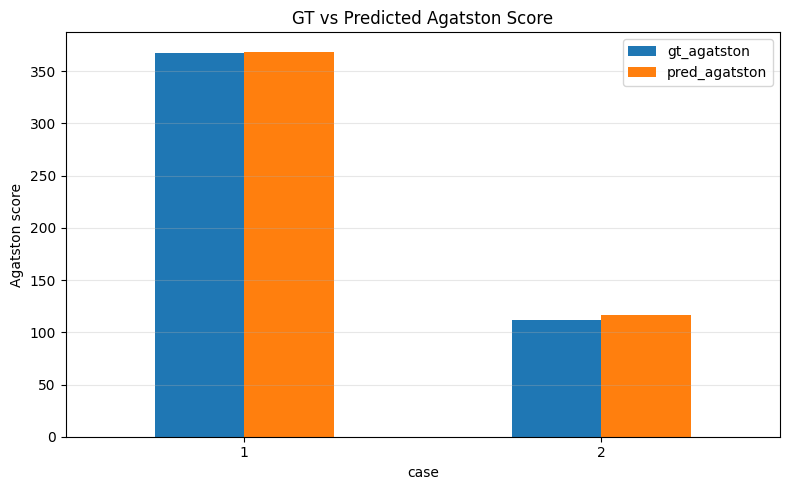

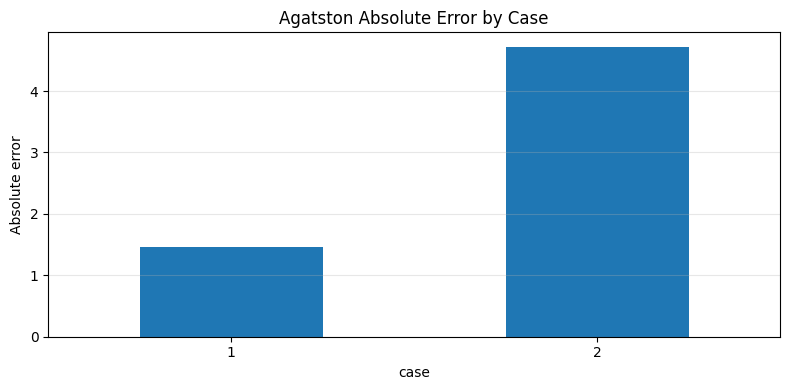

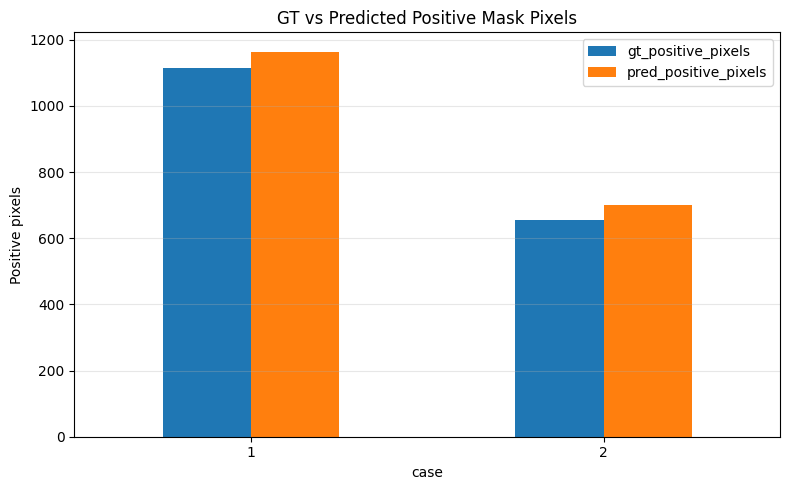

,case,gt_agatston,pred_agatston,absolute_error,relative_error,gt_positive_pixels,pred_positive_pixels,num_pred_lesions_scored,model_input_source
0,1,367.389343,368.854797,1.465454,0.003989,1115,1164,14,prepared_npy
1,2,111.628906,116.348511,4.719604,0.042279,656,700,11,prepared_npy


In [19]:
def plot_agatston_summary(pred_summary_df):
    """Plot GT vs predicted Agatston and error summaries."""
    df = pred_summary_df.copy()
    df["case"] = df["case"].astype(str)

    # 1. GT vs predicted bar chart
    ax = df.set_index("case")[["gt_agatston", "pred_agatston"]].plot(
        kind="bar",
        figsize=(8, 5),
        rot=0,
    )
    ax.set_ylabel("Agatston score")
    ax.set_title("GT vs Predicted Agatston Score")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 2. Absolute error
    ax = df.set_index("case")["absolute_error"].plot(
        kind="bar",
        figsize=(8, 4),
        rot=0,
    )
    ax.set_ylabel("Absolute error")
    ax.set_title("Agatston Absolute Error by Case")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 3. Positive pixel comparison
    ax = df.set_index("case")[["gt_positive_pixels", "pred_positive_pixels"]].plot(
        kind="bar",
        figsize=(8, 5),
        rot=0,
    )
    ax.set_ylabel("Positive pixels")
    ax.set_title("GT vs Predicted Positive Mask Pixels")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df


plot_agatston_summary(pred_summary_df)

## 17. Visualize GT vs predicted masks

Run this only after generating predicted masks.


CASE 1
HU shape: (57, 512, 512)
GT shape: (57, 512, 512)
Pred shape: (57, 512, 512)
Shape check: OK

CASE 2
HU shape: (46, 512, 512)
GT shape: (46, 512, 512)
Pred shape: (46, 512, 512)
Shape check: OK

Visualizing CASE: 1


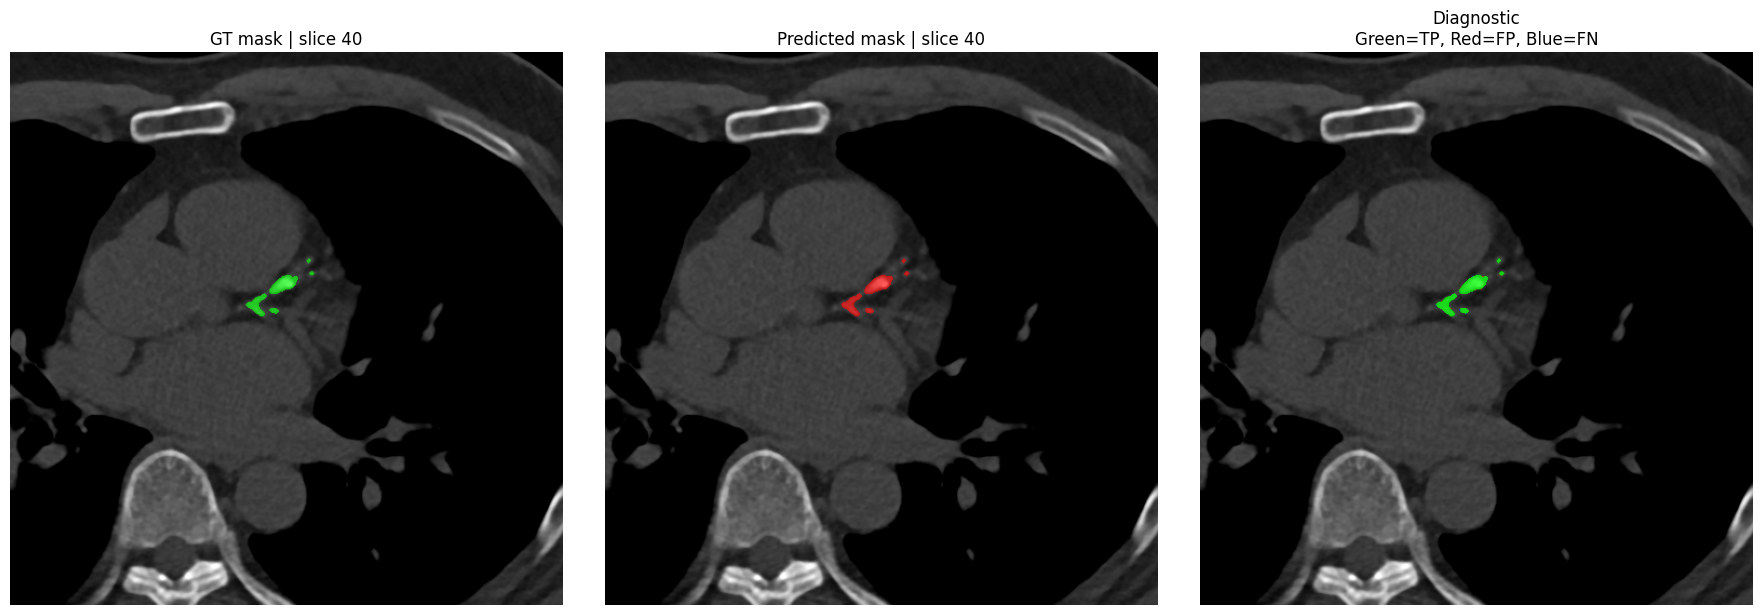


Visualizing CASE: 2


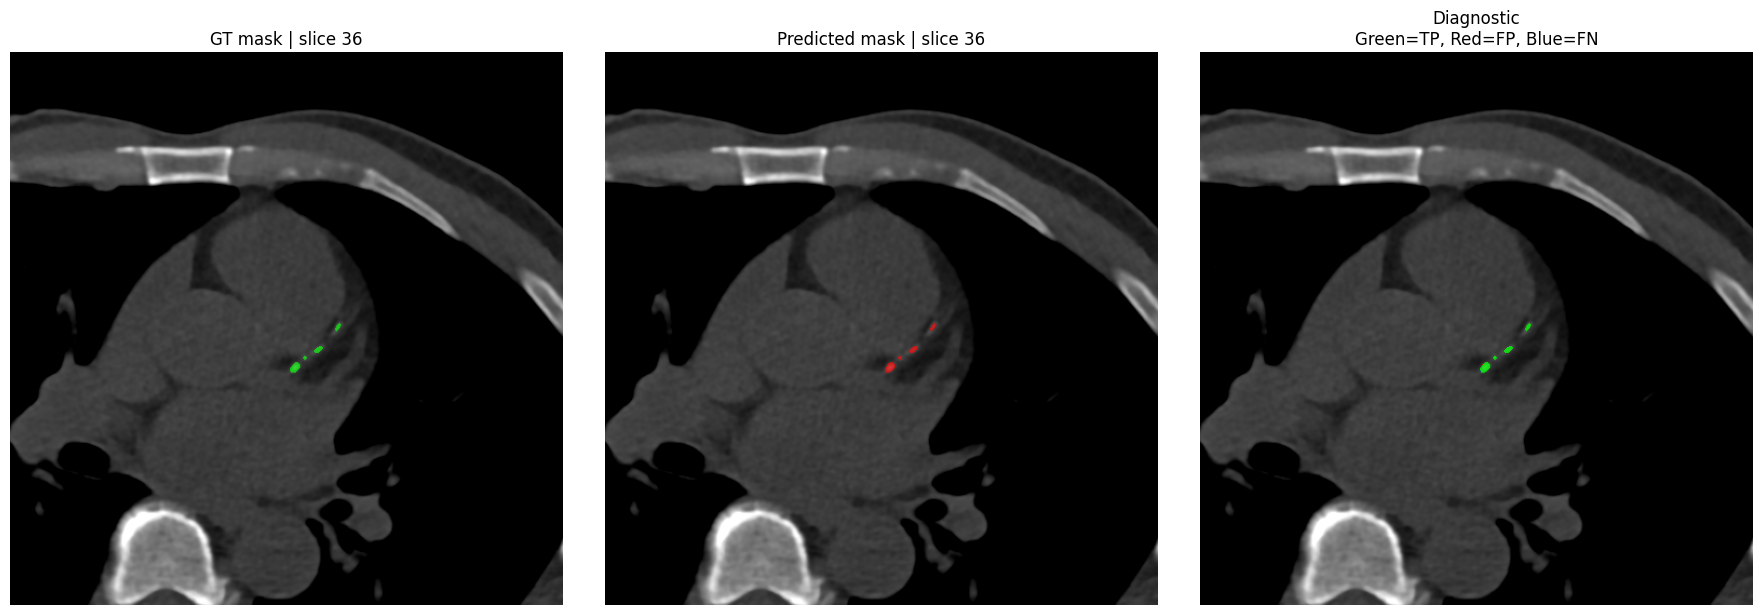

In [20]:
debug_case_shapes(case_outputs)

for case_name, outputs in case_outputs.items():
    print("\nVisualizing CASE:", case_name)

    if "pred_mask_volume" not in outputs:
        raise RuntimeError(
            f"Case {case_name} does not have pred_mask_volume. "
            "Run the prediction cell before visualization."
        )

    idx = choose_most_informative_slice(
        gt_mask=outputs["gt_mask_volume"],
        pred_mask=outputs["pred_mask_volume"],
    )

    visualize_gt_pred_side_by_side(
        hu_volume=outputs["hu_volume"],
        gt_mask=outputs["gt_mask_volume"],
        pred_mask=outputs["pred_mask_volume"],
        idx=idx,
    )

## 18. Save predicted Agatston results

Run this only after generating predicted masks.

In [ ]:
if "pred_summary_df" not in globals():
    raise RuntimeError("pred_summary_df does not exist. Run the prediction section first.")

pred_summary_df.to_csv(RESULTS_DIR / "predicted_agatston_summary.csv", index=False)

for case_name, outputs in case_outputs.items():
    case_dir = RESULTS_DIR / f"case_{case_name}"
    case_dir.mkdir(exist_ok=True)

    if "pred_lesions_df" not in outputs or "pred_mask_volume" not in outputs:
        raise RuntimeError(f"Missing predicted outputs for case {case_name}. Run prediction first.")

    outputs["pred_lesions_df"].to_csv(case_dir / "pred_lesions_agatston.csv", index=False)
    np.save(case_dir / "pred_mask_volume.npy", outputs["pred_mask_volume"])
    
print("Saved predicted results to:", RESULTS_DIR)

Saved predicted results to: agatston_results


# Final reminder

Use:

```python
gt_mask_volume + hu_volume + pixel_spacing
```

for annotation Agatston.

Use:

```python
pred_mask_volume + hu_volume + pixel_spacing
```

for predicted Agatston.

Never calculate Agatston from normalized model input.